In [ ]:
# Author: Ethan Dominic

# Import dependencies
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# The following line of code has been generated by ChatGPT 5.6
import statsmodels.api as sm

**1. Dataset loading and cleaning**

In [39]:
# 1. Dataset loading and cleaning

# Load the dataset.
churn_set = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(churn_set.columns)

# Determine the number of missing values by column in the dataset.
print("Number of Missing Values per Column:")
for col in churn_set.columns:
    print(col + ": " + str(churn_set[col].isna().sum()))

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
Number of Missing Values per Column:
customerID: 0
gender: 0
SeniorCitizen: 0
Partner: 0
Dependents: 0
tenure: 0
PhoneService: 0
MultipleLines: 0
InternetService: 0
OnlineSecurity: 0
OnlineBackup: 0
DeviceProtection: 0
TechSupport: 0
StreamingTV: 0
StreamingMovies: 0
Contract: 0
PaperlessBilling: 0
PaymentMethod: 0
MonthlyCharges: 0
TotalCharges: 0
Churn: 0


In [40]:
# Check for Logistic Regression Assumption of Independence of Observations

# The following code in this code cell was generated by ChatGPT 5.6
# Check the independence of observations.
# Each row should represent a unique customer.

# Check whether any customer IDs occur more than once.
duplicate_customer_ids = churn_set["customerID"].duplicated().sum()

print("Number of duplicate customer IDs:", duplicate_customer_ids)

if duplicate_customer_ids == 0:
    print("Independence check: No customers appear more than once.")
    print("This provides evidence that the observations are independent.")
else:
    print("Independence check: Duplicate customer IDs were found.")
    print("The data may contain repeated observations and should be investigated.")

# Check for completely duplicated rows.

duplicate_rows = churn_set.duplicated().sum()

print("Number of completely duplicated rows:", duplicate_rows)

if duplicate_rows == 0:
    print("No completely duplicated observations were found.")
else:
    print("Completely duplicated observations were found.")

Number of duplicate customer IDs: 0
Independence check: No customers appear more than once.
This provides evidence that the observations are independent.
Number of completely duplicated rows: 0
No completely duplicated observations were found.


**The Independence of observations assumption has been met.**

In [41]:
# Clean the dataset.

# Begin by removing the customer ID.
churn_set = churn_set.drop(columns=['customerID']) # Remove the customer ID

# Then, replace all the blank strings in TotalCharges with zeros. The following line of code has been generated by Claude Sonnet 5.
churn_set["TotalCharges"] = pd.to_numeric(churn_set["TotalCharges"], errors="coerce").fillna(0)

# "No internet service" is equivalent to "No". Therefore, replace "No internet service" with "No".
internet_dependent_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]
for col in churn_set[internet_dependent_cols]:
    churn_set[col] = churn_set[col].replace("No internet service", "No")

# Similarly, "No phone service" is equivalent to "No". Therefore, replace "No internet service" with "No".
churn_set["MultipleLines"] = churn_set["MultipleLines"].replace("No phone service", "No")

In [42]:
## One-hot encode the categorical columns (One-Hot encoding code courtesy of Alberto from alberto_aej_linear_regression.ipynb) <-- Originally planned for ordinal encoding to reduce dimensions but switched to one-hot encoding to ensure consistency among all notebooks.
categorical_cols = churn_set.select_dtypes(include="object").columns.tolist()
print("Categorical columns to encode:", categorical_cols)

churn_set_encoded = pd.get_dummies(churn_set, columns=categorical_cols, drop_first=True)

# get_dummies returns bool columns, convert to int for cleaner stats/plots later
bool_cols = churn_set_encoded.select_dtypes(include="bool").columns
churn_set_encoded[bool_cols] = churn_set_encoded[bool_cols].astype(int)

print(f"Encoded shape: {churn_set_encoded.shape}")
churn_set_encoded.head()

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
Encoded shape: (7043, 24)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,...,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,0,1,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42.30,1840.75,1,0,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,1,...,0,0,0,0,0,1,0,1,0,1


In [43]:
# Split the data into training and testing sets
churn_X = churn_set_encoded.drop(columns=["Churn_Yes"])
churn_y = churn_set_encoded["Churn_Yes"]
X_train, X_test, y_train, y_test = train_test_split(churn_X, churn_y, test_size=0.2, random_state=42)

**2. EDA relevant to logistic regression assumptions.**

In [44]:
# 2. EDA relevant to logistic regression assumptions.

# Binary outcome: The response is a category with two levels

# If the target (Churn) only has two values (0 and 1), this assumption has been met
print(churn_y.nunique() == 2)

# The binary outcome assumption has been met!

True


The Binary outcome assumption has been met.

In [45]:
"""
Limited multicollinearity: Highly correlated predictors inflate standard errors
and make individual coefficients unstable, just as in linear regression.
"""
# Create a correlation matrix for all the numerical columns.
corr_matrix = X_train.corr()
print(corr_matrix)

                                       SeniorCitizen    tenure  \
SeniorCitizen                               1.000000  0.008823   
tenure                                      0.008823  1.000000   
MonthlyCharges                              0.217649  0.253803   
TotalCharges                                0.095708  0.828060   
gender_Male                                -0.005081  0.000682   
Partner_Yes                                 0.014493  0.378964   
Dependents_Yes                             -0.211807  0.162235   
PhoneService_Yes                            0.004497  0.006502   
MultipleLines_Yes                           0.125617  0.337808   
InternetService_Fiber optic                 0.255031  0.025566   
InternetService_No                         -0.183585 -0.045038   
OnlineSecurity_Yes                         -0.036259  0.327292   
OnlineBackup_Yes                            0.066739  0.358333   
DeviceProtection_Yes                        0.063601  0.361765   
TechSuppor

In [46]:
"""
The most correlated pairs of features are tenure and TotalCharges (about 0.83
correlation value) as well as MonthlyCharges and InternetService_Fiber optic (about
0.79 correlation value). Remove TotalCharges and MonthlyCharges since both of these
features correlated with each other as well (approximately 0.65 correlation value).
"""
X_train = X_train.drop(columns=["TotalCharges", "MonthlyCharges"])

The Limited multicollinearity assumption has been met.

In [47]:
"""
Sufficient sample size: A common rule of thumb is at least 10–20 events per predictor.
Sparse data leads to unreliable coefficients and over-fit decision boundaries.
"""

# Store the dimensions
dimensions = X_train.shape
num_rows = dimensions[0]
num_cols = dimensions[1]

# Report counts of missing values per column.
print("")
print("Number of Missing Values per Column:")
for col in X_train.columns:
    print(col + ": " + str(X_train[col].isna().sum()))
print("")

# Create a mapping of the columns to the corresponding percentages of values missing.
cols_to_percentage_missing = {}

# Print the percentage of values missing per column.
print("Percentage of Values Missing per Column:")
for col in X_train.columns:
    print(col + ": " + str(100*X_train[col].isna().sum()/num_rows) + "%")
    cols_to_percentage_missing[col] = 100*X_train[col].isna().sum()/num_rows
print("")


Number of Missing Values per Column:
SeniorCitizen: 0
tenure: 0
gender_Male: 0
Partner_Yes: 0
Dependents_Yes: 0
PhoneService_Yes: 0
MultipleLines_Yes: 0
InternetService_Fiber optic: 0
InternetService_No: 0
OnlineSecurity_Yes: 0
OnlineBackup_Yes: 0
DeviceProtection_Yes: 0
TechSupport_Yes: 0
StreamingTV_Yes: 0
StreamingMovies_Yes: 0
Contract_One year: 0
Contract_Two year: 0
PaperlessBilling_Yes: 0
PaymentMethod_Credit card (automatic): 0
PaymentMethod_Electronic check: 0
PaymentMethod_Mailed check: 0

Percentage of Values Missing per Column:
SeniorCitizen: 0.0%
tenure: 0.0%
gender_Male: 0.0%
Partner_Yes: 0.0%
Dependents_Yes: 0.0%
PhoneService_Yes: 0.0%
MultipleLines_Yes: 0.0%
InternetService_Fiber optic: 0.0%
InternetService_No: 0.0%
OnlineSecurity_Yes: 0.0%
OnlineBackup_Yes: 0.0%
DeviceProtection_Yes: 0.0%
TechSupport_Yes: 0.0%
StreamingTV_Yes: 0.0%
StreamingMovies_Yes: 0.0%
Contract_One year: 0.0%
Contract_Two year: 0.0%
PaperlessBilling_Yes: 0.0%
PaymentMethod_Credit card (automatic)

In [48]:
"""
There are no missing values in the train feature set as shown above. As a result,
if there are at least 10 observations, this test pass.
"""
print(num_rows > 10)

"""
There are at least 10 observations meaning that the Sufficient Sample Size assumption
has been met.
"""

True


'\nThere are at least 10 observations meaning that the Sufficient Sample Size assumption\nhas been met.\n'

**The Sufficient sample size assumption has been met.**

3. Logistic Regression Model Code

In [49]:
# 3. Logistic Regression Model Code
model = LogisticRegression(max_iter=1000) # max_iter=1000 portion of line of code generated by ChatGPT 5.6
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [50]:
# Drop the MonthlyCharges and TotalCharges columns for consistency with the train set
X_test_transformed = X_test.drop(columns=["TotalCharges", "MonthlyCharges"])

# Make the predictions
predictions = model.predict(X_test_transformed)

4. Model performance evidence

In [51]:
# 4. Model performance evidence

# Calculate the accuracy score of the trained model on the test set.
accuracy = accuracy_score(y_test, predictions)
print("Model Accuracy:", accuracy)

# The model's accuracy is approximately 82%.

Model Accuracy: 0.8211497515968772


4.5 Continuation Of Logistic Regression Assumptions Check

In [52]:
"""
No perfect separation:  If one feature (or combination of features) perfectly predicts
the outcome, the algorithm cannot converge and coefficients inflate without bound.
"""

# The following code in this code cell was generated by ChatGPT 5.6
if model.n_iter_[0] < 1000:
    print("No convergence problem detected.")
    print("The logistic regression model converged before reaching the maximum iterations.")
else:
    print("Potential convergence problem detected.")
    print("Consider investigating possible perfect or quasi-perfect separation.")

# Check categorical/binary predictors for possible perfect separation.

separation_candidates = []

for column in X_train.columns:
    if X_train[column].nunique() <= 2:
        contingency_table = pd.crosstab(X_train[column], y_train)

        # If any category has observations from only one outcome class,
        # it may be a candidate for separation.
        if (contingency_table == 0).any(axis=1).any():
            separation_candidates.append(column)

print("Potential separation candidates:")
print(separation_candidates)

if len(separation_candidates) == 0:
    print("No obvious categorical predictors showing complete separation were found.")
else:
    print("Some predictors may exhibit complete or quasi-complete separation.")
    print("These predictors should be investigated further.")

No convergence problem detected.
The logistic regression model converged before reaching the maximum iterations.
Potential separation candidates:
[]
No obvious categorical predictors showing complete separation were found.


**The no perfect separation assumption has been met.**

Continuous predictors:
['tenure']


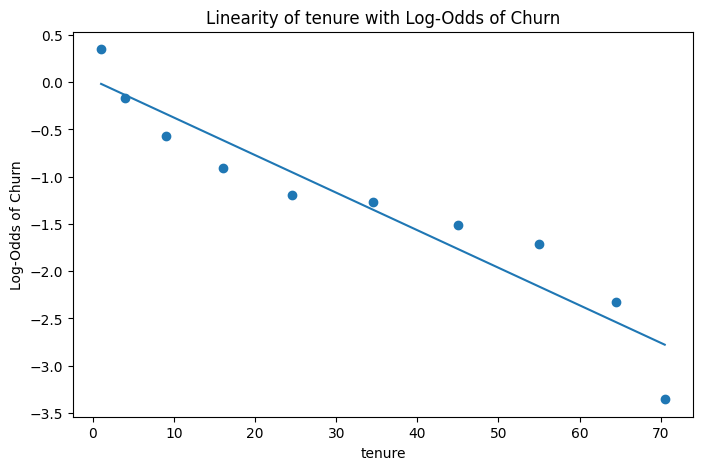

In [53]:
"""
Linear log-odds: The model assumes each feature has a straight-line relationship
with the log-odds of the outcome. Non-linear effects need splines, interactions,
or transformations.
"""
# The following code in this code cell was generated by ChatGPT 5.6
# Identify continuous predictors.
# Binary variables (0/1) are excluded because the linearity-in-log-odds
# assumption applies to continuous predictors.

continuous_features = [
    column for column in X_train.columns
    if X_train[column].nunique() > 2
]

print("Continuous predictors:")
print(continuous_features)

# Check the linearity of continuous predictors with the log-odds.
#
# The predictor is divided into bins. For each bin, we calculate:
# log-odds = log(p / (1-p))
#
# A roughly straight-line pattern provides evidence supporting
# the linearity-in-log-odds assumption.

for feature in continuous_features:

    # Create bins containing approximately equal numbers of observations.
    temp = pd.DataFrame({
        "feature": X_train[feature],
        "outcome": y_train
    }).copy()

    temp["bin"] = pd.qcut(
        temp["feature"],
        q=10,
        duplicates="drop"
    )

    # Calculate the proportion of churn in each bin.
    grouped = temp.groupby("bin", observed=True)["outcome"].agg(
        ["mean", "count"]
    )

    # Avoid log(0) and log(infinity).
    epsilon = 0.001
    probabilities = grouped["mean"].clip(epsilon, 1 - epsilon)

    log_odds = np.log(
        probabilities / (1 - probabilities)
    )

    # Use the midpoint of each bin for the x-axis.
    bin_midpoints = [
        interval.mid for interval in grouped.index
    ]

    plt.figure(figsize=(8, 5))

    plt.scatter(
        bin_midpoints,
        log_odds
    )

    # Add a linear trend line.
    z = np.polyfit(bin_midpoints, log_odds, 1)
    trend = np.poly1d(z)

    plt.plot(
        bin_midpoints,
        trend(bin_midpoints)
    )

    plt.xlabel(feature)
    plt.ylabel("Log-Odds of Churn")
    plt.title(
        f"Linearity of {feature} with Log-Odds of Churn"
    )

    plt.show()

**Tenure appears to have a linear relationship with the Log-Odds of Churn, meaning that the Linear Log-Odds assumption has been met.**

**5. Coefficient or odds-ratio interpretation in markdown.**

In [54]:
model_columns = X_train.columns
X_train.columns

Index(['SeniorCitizen', 'tenure', 'gender_Male', 'Partner_Yes',
       'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes',
       'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [55]:
feature_coefficients = model.coef_
print(feature_coefficients)

[[ 0.1631202  -0.03297277 -0.05237083  0.05541295 -0.17495638 -0.51093215
   0.28565602  0.86917602 -0.78558268 -0.41216904 -0.13793308  0.0052837
  -0.32891483  0.23081812  0.33588604 -0.63800668 -1.37739622  0.3321815
  -0.09002063  0.32814267  0.00825507]]


In [56]:
# The following code cell's code was generated by ChatGPT 5.6
feature_coefficients = model.coef_[0]

feature_coefficient_dict = {
    feature: float(coef)
    for feature, coef in zip(model_columns, feature_coefficients)
}

print(feature_coefficient_dict)

{'SeniorCitizen': 0.16312020439311975, 'tenure': -0.032972773013396794, 'gender_Male': -0.05237083105349236, 'Partner_Yes': 0.05541294727980093, 'Dependents_Yes': -0.17495638353344645, 'PhoneService_Yes': -0.5109321474175597, 'MultipleLines_Yes': 0.2856560197070495, 'InternetService_Fiber optic': 0.8691760210643683, 'InternetService_No': -0.7855826805466692, 'OnlineSecurity_Yes': -0.4121690404214305, 'OnlineBackup_Yes': -0.1379330758773175, 'DeviceProtection_Yes': 0.005283696466589421, 'TechSupport_Yes': -0.3289148252899699, 'StreamingTV_Yes': 0.23081811985381184, 'StreamingMovies_Yes': 0.3358860351412584, 'Contract_One year': -0.6380066780206062, 'Contract_Two year': -1.3773962227380214, 'PaperlessBilling_Yes': 0.33218150449967454, 'PaymentMethod_Credit card (automatic)': -0.0900206274662457, 'PaymentMethod_Electronic check': 0.32814266665919256, 'PaymentMethod_Mailed check': 0.008255071629474019}


In [57]:
for feature in feature_coefficient_dict:
    if feature_coefficient_dict[feature] >= 0:
        print(f"{feature}: The coefficient for {feature} is {feature_coefficient_dict[feature]}. This means that, holding all other variables, constant, a one unit increase in {feature} results in a {feature_coefficient_dict[feature]} increase in the log-odds of churn.")
    else:
        print(f"{feature}: The coefficient for {feature} is {feature_coefficient_dict[feature]}. This means that, holding all other variables, constant, a one unit increase in {feature} results in a {-1*feature_coefficient_dict[feature]} decrease in the log-odds of churn.")



SeniorCitizen: The coefficient for SeniorCitizen is 0.16312020439311975. This means that, holding all other variables, constant, a one unit increase in SeniorCitizen results in a 0.16312020439311975 increase in the log-odds of churn.
tenure: The coefficient for tenure is -0.032972773013396794. This means that, holding all other variables, constant, a one unit increase in tenure results in a 0.032972773013396794 decrease in the log-odds of churn.
gender_Male: The coefficient for gender_Male is -0.05237083105349236. This means that, holding all other variables, constant, a one unit increase in gender_Male results in a 0.05237083105349236 decrease in the log-odds of churn.
Partner_Yes: The coefficient for Partner_Yes is 0.05541294727980093. This means that, holding all other variables, constant, a one unit increase in Partner_Yes results in a 0.05541294727980093 increase in the log-odds of churn.
Dependents_Yes: The coefficient for Dependents_Yes is -0.17495638353344645. This means that, 

**SeniorCitizen**: The coefficient for SeniorCitizen is 0.16312020439311975. This means that, holding all other variables, constant, a one unit increase in SeniorCitizen results in a 0.16312020439311975 increase in the log-odds of churn.

**tenure**: The coefficient for tenure is -0.032972773013396794. This means that, holding all other variables, constant, a one unit increase in tenure results in a 0.032972773013396794 decrease in the log-odds of churn.

**gender_Male**: The coefficient for gender_Male is -0.05237083105349236. This means that, holding all other variables, constant, a one unit increase in gender_Male results in a 0.05237083105349236 decrease in the log-odds of churn.

**Partner_Yes**: The coefficient for Partner_Yes is 0.05541294727980093. This means that, holding all other variables, constant, a one unit increase in Partner_Yes results in a 0.05541294727980093 increase in the log-odds of churn.

**Dependents_Yes**: The coefficient for Dependents_Yes is -0.17495638353344645. This means that, holding all other variables, constant, a one unit increase in Dependents_Yes results in a 0.17495638353344645 decrease in the log-odds of churn.

**PhoneService_Yes**: The coefficient for PhoneService_Yes is -0.5109321474175597. This means that, holding all other variables, constant, a one unit increase in PhoneService_Yes results in a 0.5109321474175597 decrease in the log-odds of churn.

**MultipleLines_Yes**: The coefficient for MultipleLines_Yes is 0.2856560197070495. This means that, holding all other variables, constant, a one unit increase in MultipleLines_Yes results in a 0.2856560197070495 increase in the log-odds of churn.

**InternetService_Fiber optic**: The coefficient for InternetService_Fiber optic is 0.8691760210643683. This means that, holding all other variables, constant, a one unit increase in InternetService_Fiber optic results in a 0.8691760210643683 increase in the log-odds of churn.

**InternetService_No**: The coefficient for InternetService_No is -0.7855826805466692. This means that, holding all other variables, constant, a one unit increase in InternetService_No results in a 0.7855826805466692 decrease in the log-odds of churn.

**OnlineSecurity_Yes**: The coefficient for OnlineSecurity_Yes is -0.4121690404214305. This means that, holding all other variables, constant, a one unit increase in OnlineSecurity_Yes results in a 0.4121690404214305 decrease in the log-odds of churn.

**OnlineBackup_Yes**: The coefficient for OnlineBackup_Yes is -0.1379330758773175. This means that, holding all other variables, constant, a one unit increase in OnlineBackup_Yes results in a 0.1379330758773175 decrease in the log-odds of churn.

**DeviceProtection_Yes**: The coefficient for DeviceProtection_Yes is 0.005283696466589421. This means that, holding all other variables, constant, a one unit increase in DeviceProtection_Yes results in a 0.005283696466589421 increase in the log-odds of churn.

**TechSupport_Yes**: The coefficient for TechSupport_Yes is -0.3289148252899699. This means that, holding all other variables, constant, a one unit increase in TechSupport_Yes results in a 0.3289148252899699 decrease in the log-odds of churn.

**StreamingTV_Yes**: The coefficient for StreamingTV_Yes is 0.23081811985381184. This means that, holding all other variables, constant, a one unit increase in StreamingTV_Yes results in a 0.23081811985381184 increase in the log-odds of churn.

**StreamingMovies_Yes**: The coefficient for StreamingMovies_Yes is 0.3358860351412584. This means that, holding all other variables, constant, a one unit increase in StreamingMovies_Yes results in a 0.3358860351412584 increase in the log-odds of churn.

**Contract_One year**: The coefficient for Contract_One year is -0.6380066780206062. This means that, holding all other variables, constant, a one unit increase in Contract_One year results in a 0.6380066780206062 decrease in the log-odds of churn.

**Contract_Two year**: The coefficient for Contract_Two year is -1.3773962227380214. This means that, holding all other variables, constant, a one unit increase in Contract_Two year results in a 1.3773962227380214 decrease in the log-odds of churn.

**PaperlessBilling_Yes**: The coefficient for PaperlessBilling_Yes is 0.33218150449967454. This means that, holding all other variables, constant, a one unit increase in PaperlessBilling_Yes results in a 0.33218150449967454 increase in the log-odds of churn.

**PaymentMethod_Credit card (automatic)**: The coefficient for PaymentMethod_Credit card (automatic) is -0.0900206274662457. This means that, holding all other variables, constant, a one unit increase in PaymentMethod_Credit card (automatic) results in a 0.0900206274662457 decrease in the log-odds of churn.

**PaymentMethod_Electronic check**: The coefficient for PaymentMethod_Electronic check is 0.32814266665919256. This means that, holding all other variables, constant, a one unit increase in PaymentMethod_Electronic check results in a 0.32814266665919256 increase in the log-odds of churn.

**PaymentMethod_Mailed check**: The coefficient for PaymentMethod_Mailed check is 0.008255071629474019. This means that, holding all other variables, constant, a one unit increase in PaymentMethod_Mailed check results in a 0.008255071629474019 increase in the log-odds of churn.

6. At least one limitation of using logistic regression for churn.

**A limitation of using logistic regression for churn is that this model cannot inherently account for potential relationships between churn and interaction terms between the features during training (which might be contributing to the suboptimal accuracy score of 82% on the test set).**

**Note: This answer was written based on a conversation with Claude Sonnet 5 - to be clear though, this answer is written by me in my own words and through my own thinking.**